# **Compare and Analyze Training Results**

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2
from gbmhackathon.training.cv import plot_cv_table, plot_results_cv

## **All results**

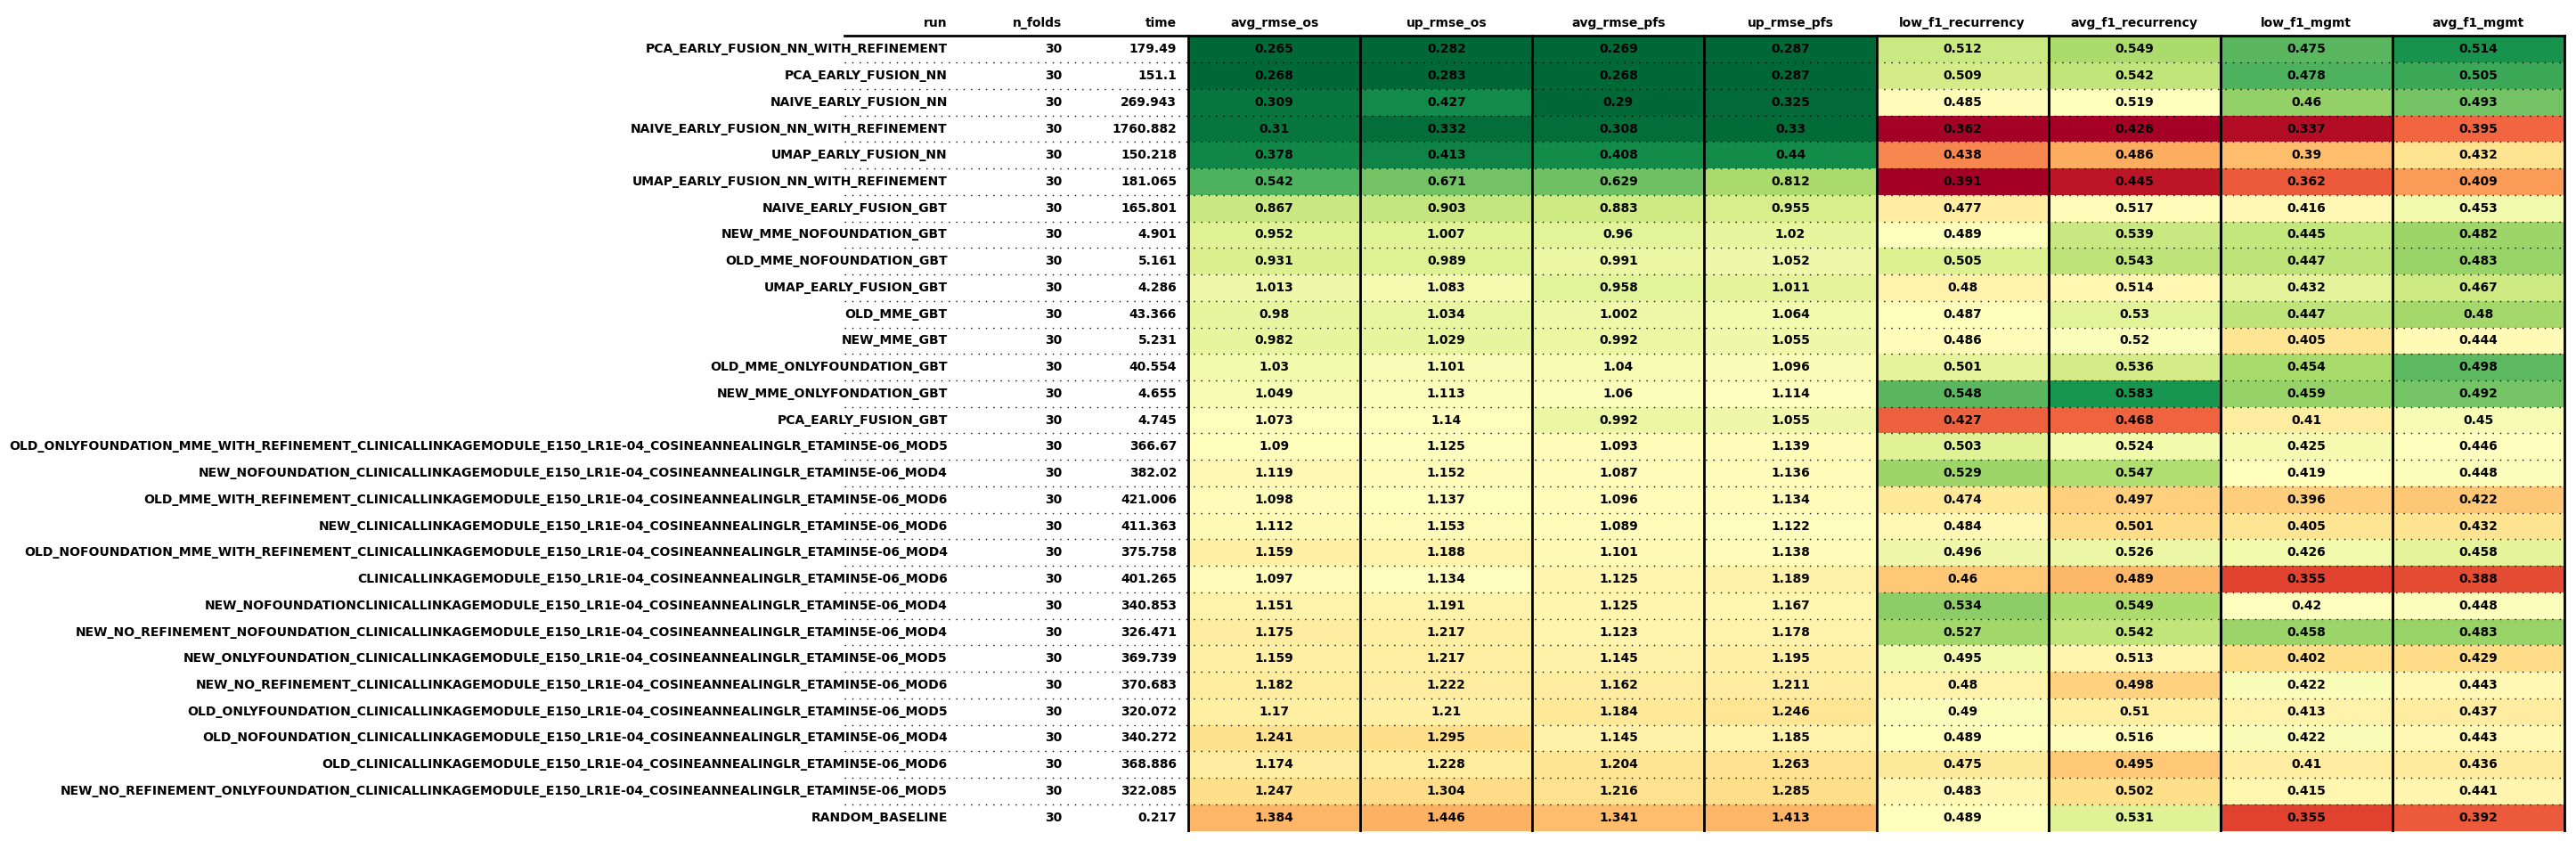

In [3]:
plot_cv_table('../results/cv_results.csv', figsize=(25,12))

### That's a lot, let's dive into it
## **Early Fusion**

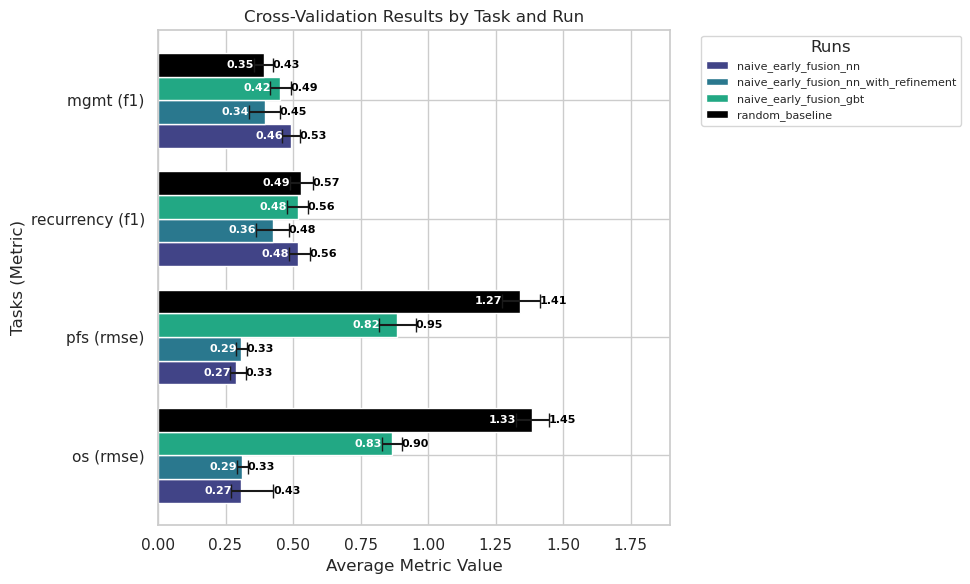

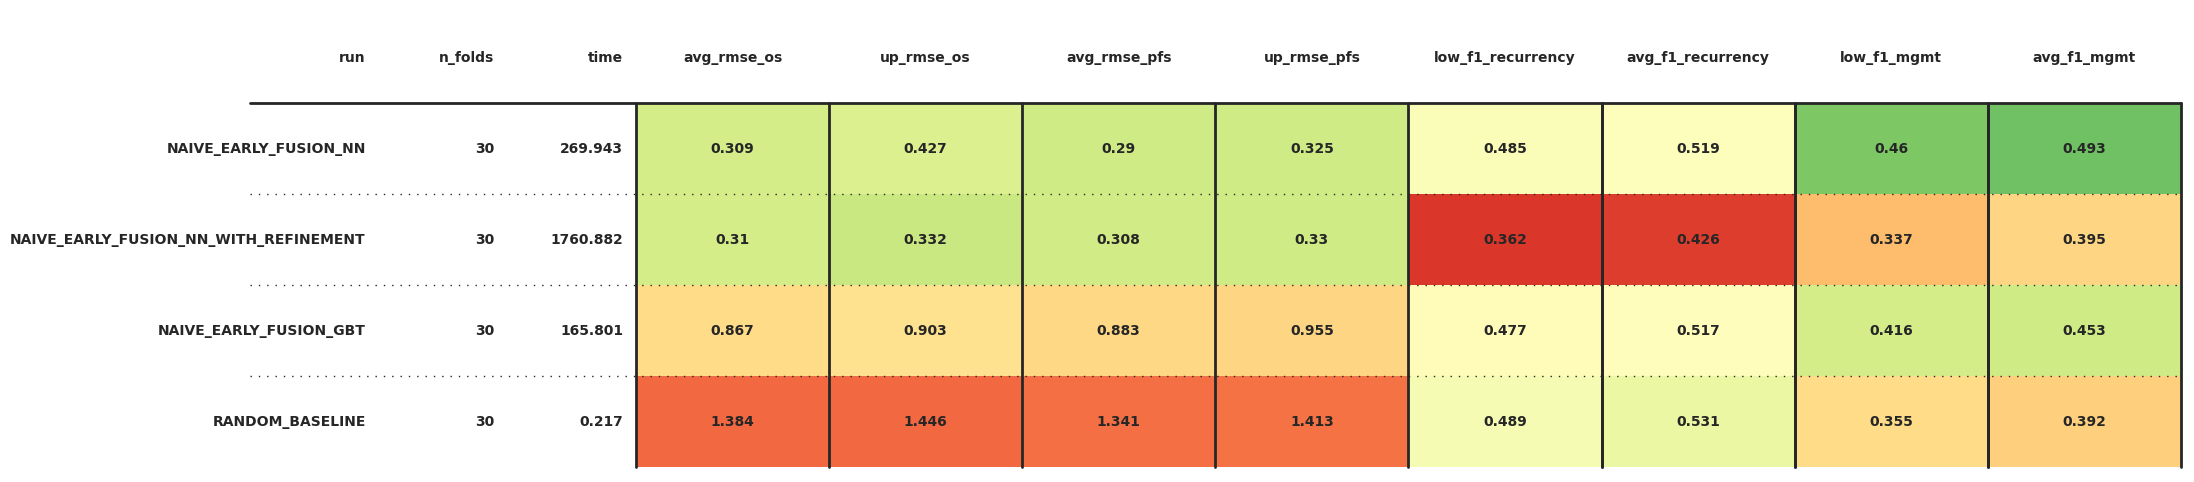

In [4]:
plot_results_cv('../results/cv_results.csv', run_filter='naive_early', figsize=(10,6))

Regression results are good when using the Neural network. They are similar with or without the refinement block. Overall, appraoches are useful if we compare them to a random baseline on regression tasks.
Classification results are not good regardless of using ML or DL since, overall, they have similar confidence intervals as the random baseline. Globally, the Gradient Boosting Tree does not perform very well in this setting which is expected due to the extremely large dimensionality of the feature space (9554). It seems to suffer from the curse of dimensionality.  
Best performances are obtained with **Naive Fusion with an ensemble of MLPs (1 per task)**:  
**Overall Survival (os) = 0.309**  
**Progression Free Years (pfs) = 0.29**   
**Recurrency = 0.519**   
**MGMT Promoter Methylation = 0.493**   
Can we improve performance by reducing the dimension ?

/home/sagemaker-user/gbm_hackathon/gbmhackathon/training/cv.py:262: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[df['run'].str.contains(run_filter)]


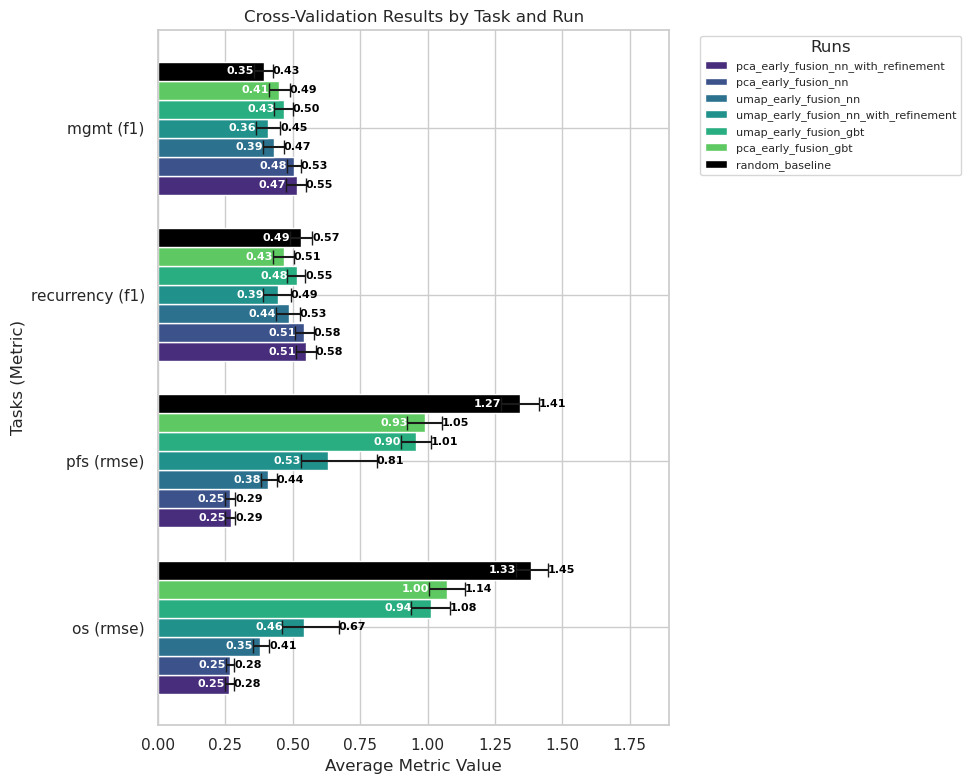

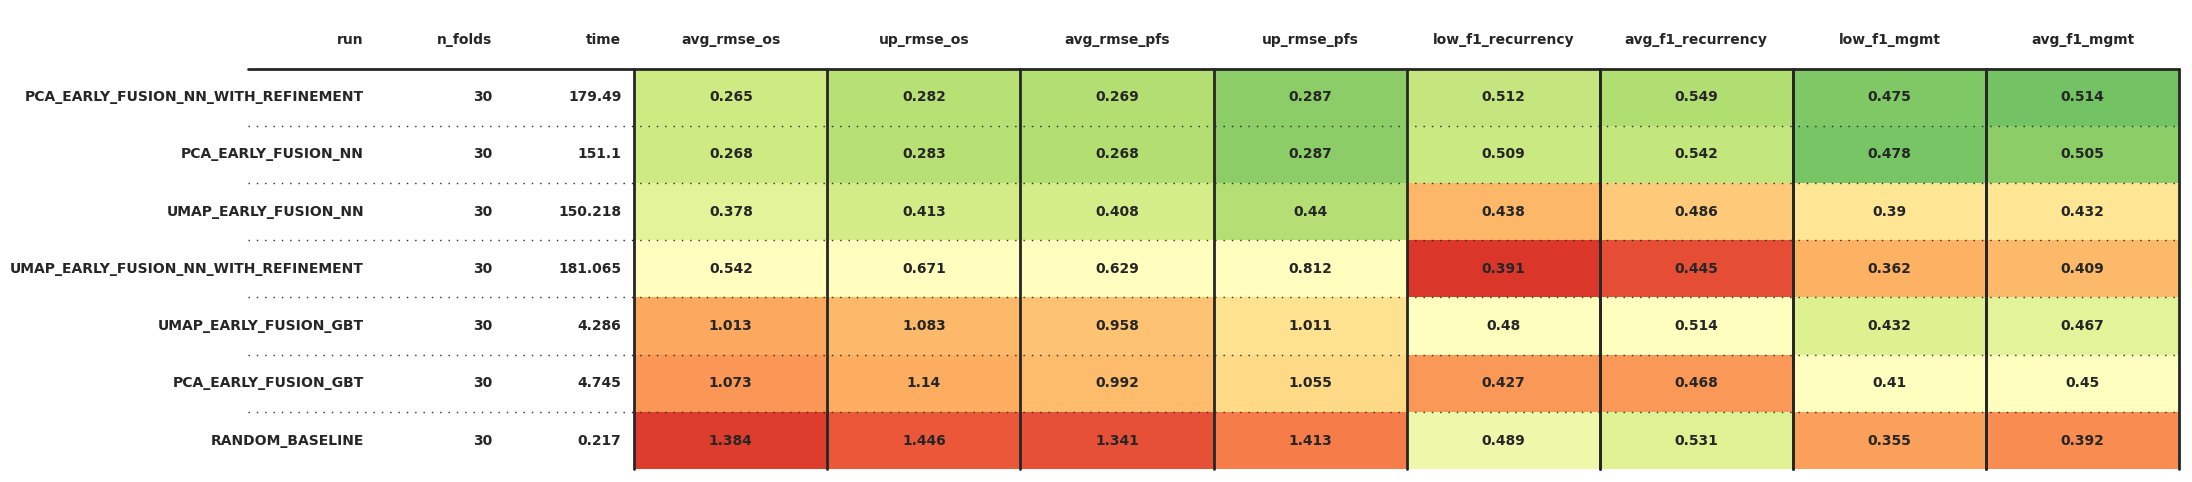

In [5]:
plot_results_cv('../results/cv_results.csv', run_filter='(pca|umap)_early_fusion')

Using Dimensionality reduction slightly improve results when using the neural network. Surprinsingly, the gradient boosting tree does not improve and even gets slightly worse results which was not expected. UMAP reduction step yields worse downstream performances than PCA.  
Best performances are obtained with **Early Fusion with PCA with our clinical linkage module (RefinementBlock + 1 MLP per task)**:  
**Overall Survival (os) = 0.265 (14% performance increase)**   
**Progression Free Years (pfs) = 0.269 (7% performance increase)**  
**Recurrency = 0.549 (5% performance increase)**  
**MGMT Promoter Methylation = 0.514 (4% performance increase)**  

### **Conclusion on Early Fusion**
The above results suggest that using a Neural network is indeed a viable approach even for this very low-N setting. Using PCA improves results. The refinement block does not yield significantly different results compared to the ensemble of MLPs alone. A surprising result stems from the inability of the gradient boosting tree to effectively predict regression targets from the input feature space. On regression task, both ML and DL appraoches are limited and close to the random baseline (except NN with PCA)

## **THREADS-like contrastive phase (old framework)**

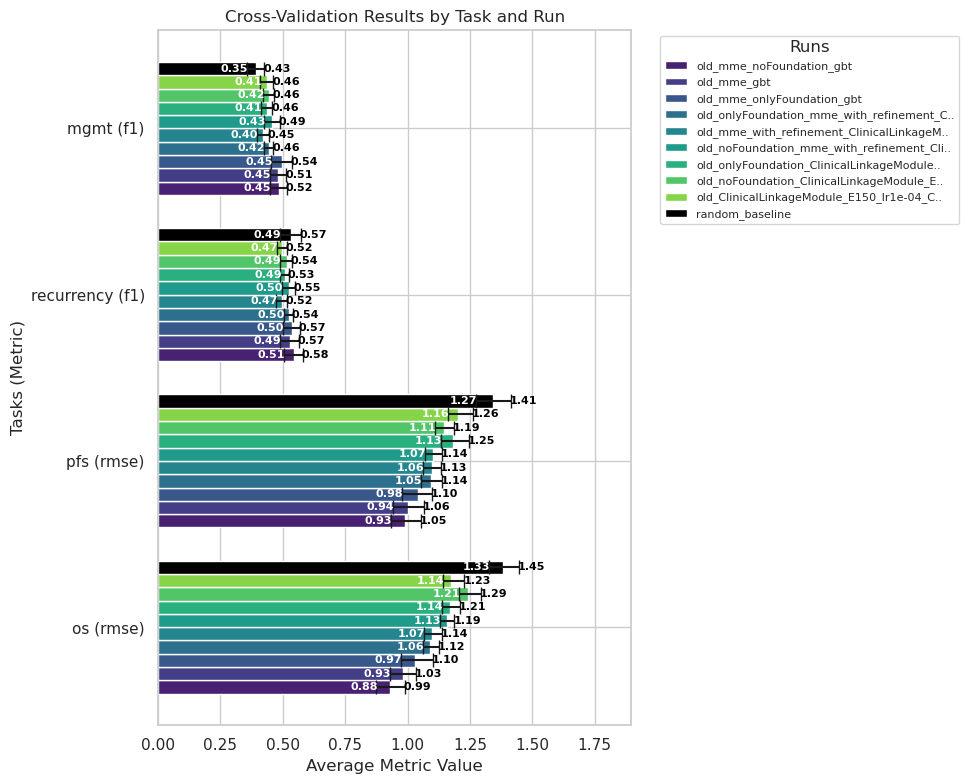

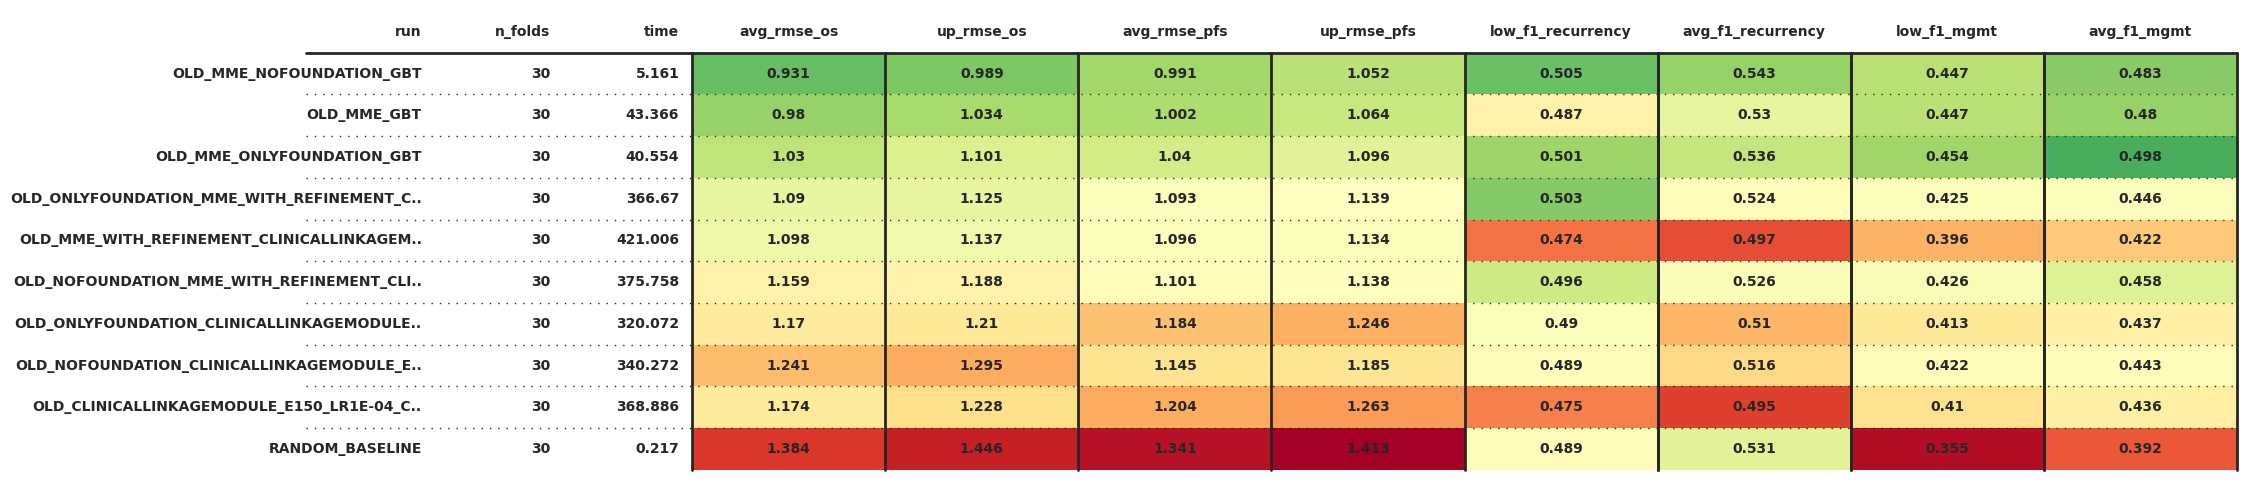

In [6]:
plot_results_cv('../results/cv_results.csv', run_filter='old', clip_runs=True)

The framework is no better than the random baseline on classification tasks. It does beat the random baseline on regression tasks, however it is much worse than what we previously obtained using PCA and Early Fusion which is not what was expected. This suggests that the information is harder to extract after the contrastive phase and thus that we may have lost significant parts of the signal by doing so. When using this framework DL and ML approaches perform similarly.  

Nonetheless, the **best** result obtained using this framework is when using the **Gradient Boosting Trees** algorithm on a dataset only using **Clinical, WES, Bulk and scRNA data with raw embeddings (no Foundation models in any modality)**. We can also note that the same run **using only foundation models modalities (HnE, Spatial, Bulk, scRNA)**, yields **better results for MGMT Promoter methylation prediction**, it performs similarly on Recurrency and is worse on both regression tasks.

## **Modality wise contrastive phase (new framework)**

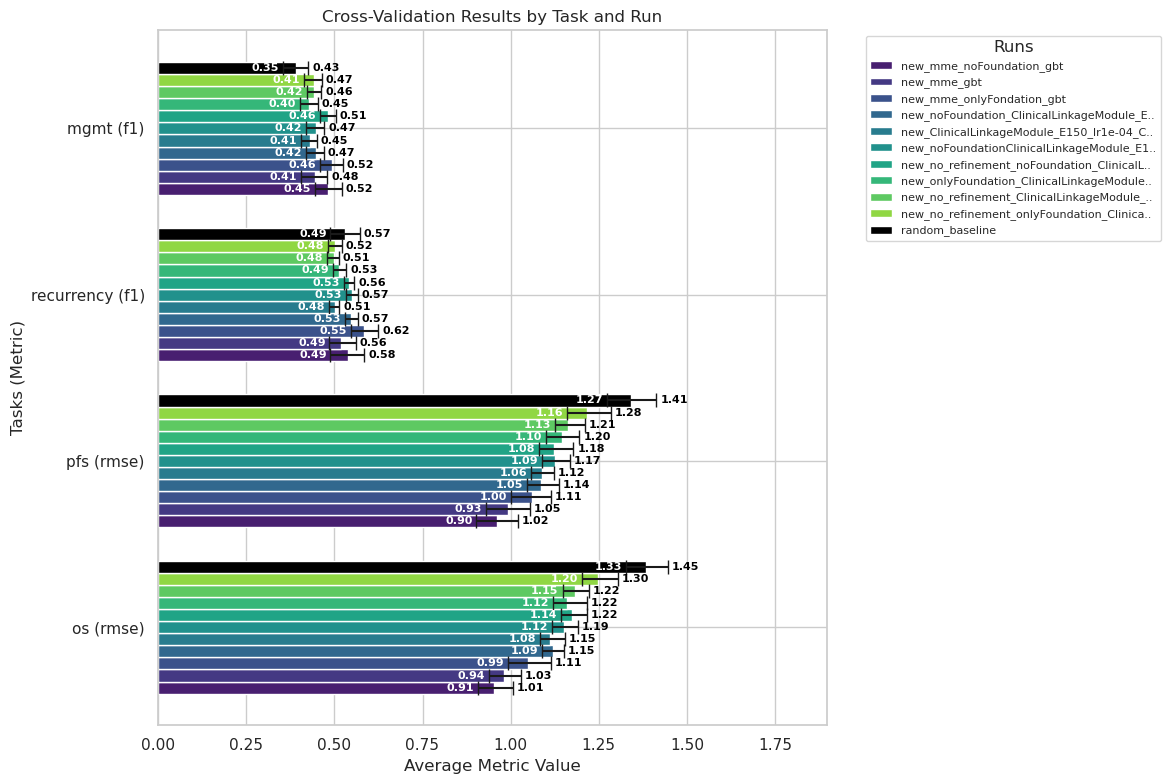

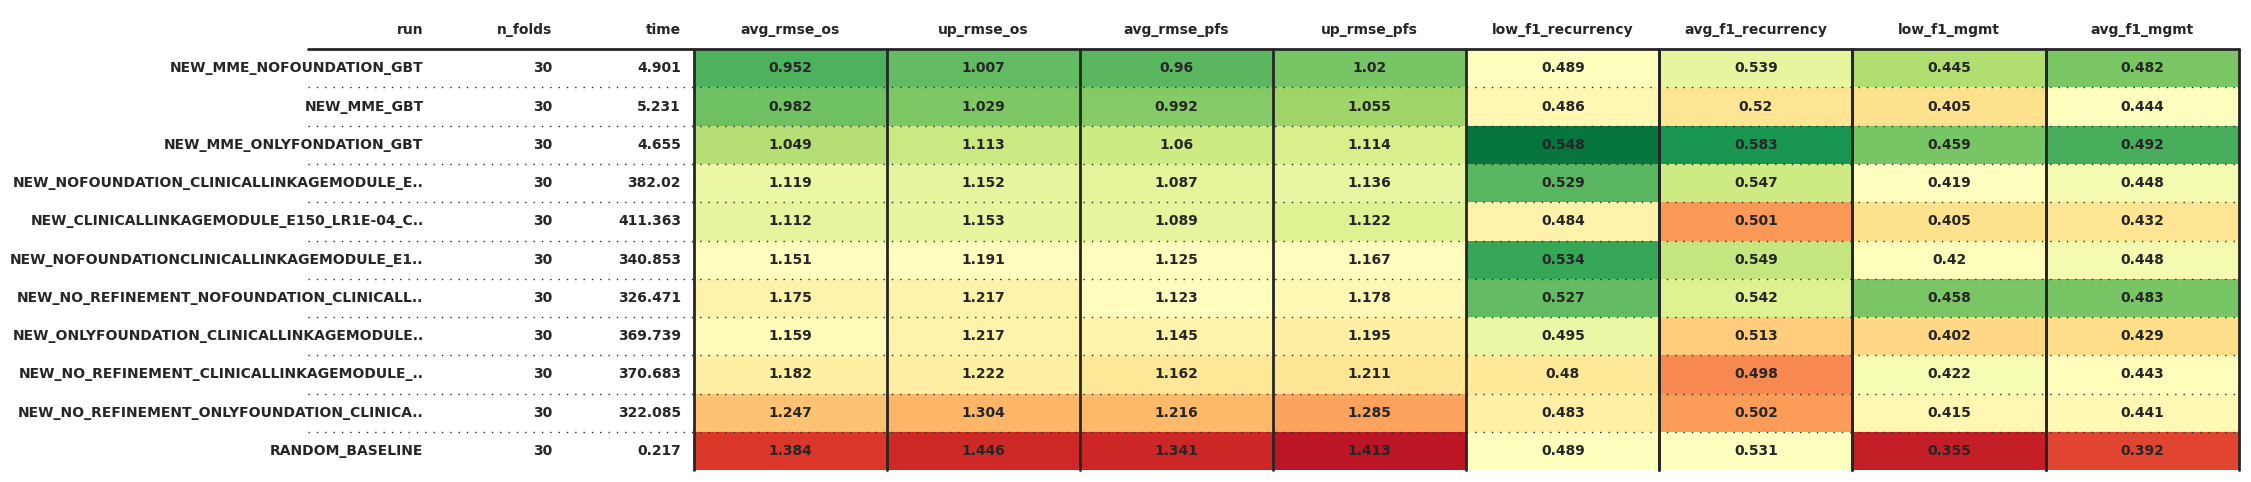

In [8]:
plot_results_cv('../results/cv_results.csv', run_filter='new', clip_runs=True, figsize=(12,8))

Similar conclusions to the THREADS-like framework can be made on the modality wise framework.   
**Let's look at both frameworks best results and compare them with early fusion best.**

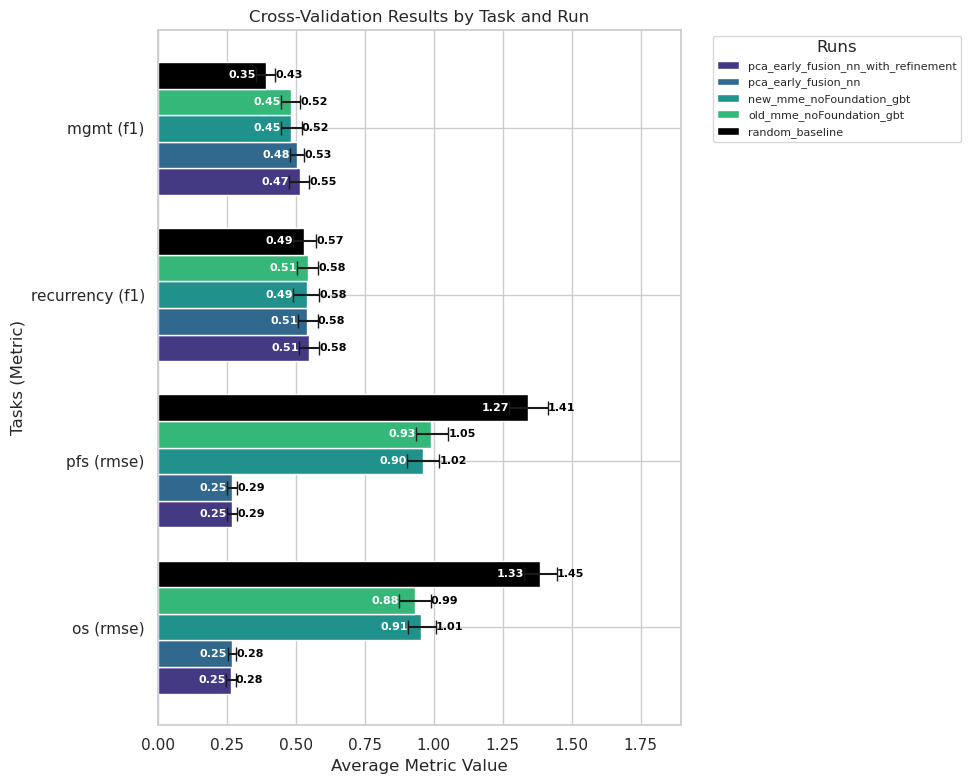

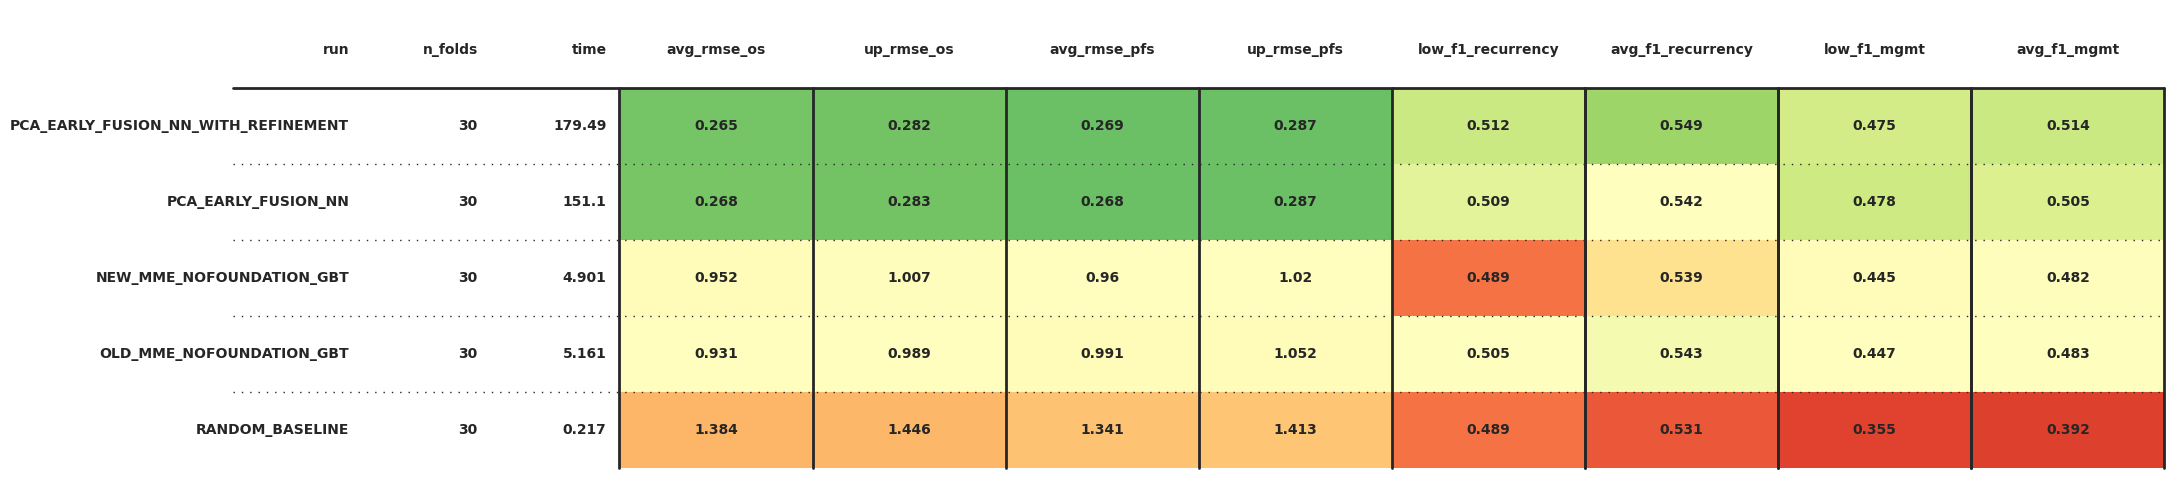

In [13]:
plot_results_cv('../results/cv_results.csv', run_filter='mme_noFoundation|pca_early_fusion_nn', clip_runs=True)

**There is no significant difference between both frameworks**. The contrastive approaches lead to **similar results for classification tasks** as those obtained using early fusion with PCA. **No matter the approach, no significant difference can be made compared to the random baseline on classification tasks**. However, results are significantly worse on regression tasks.

## **Focus on CLinicalLinkageModule**

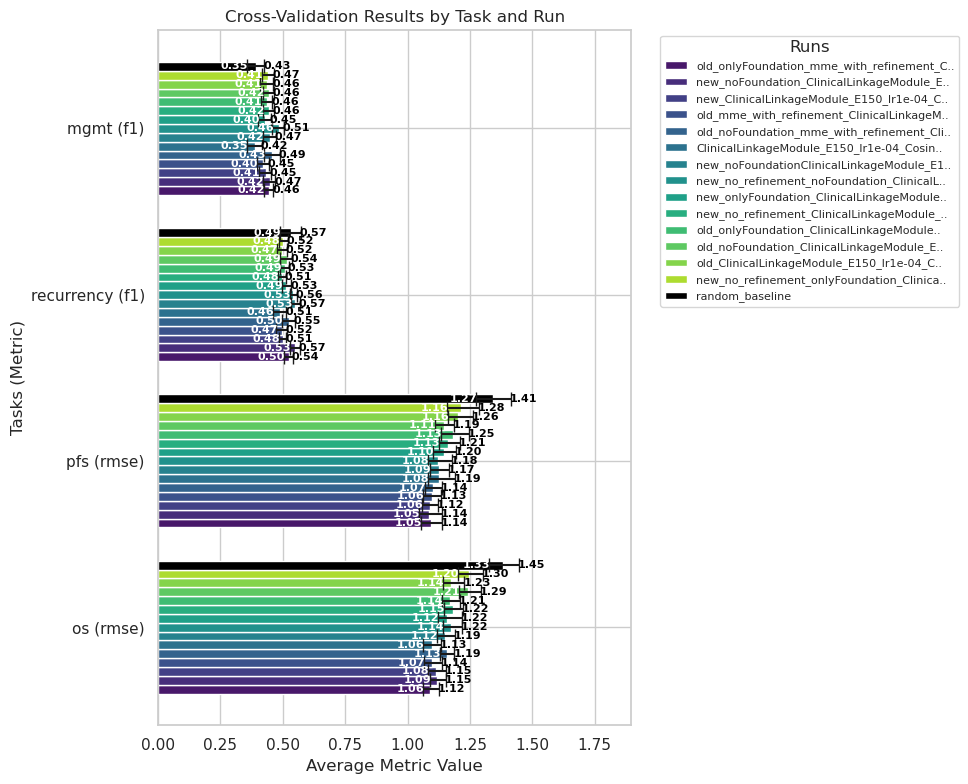

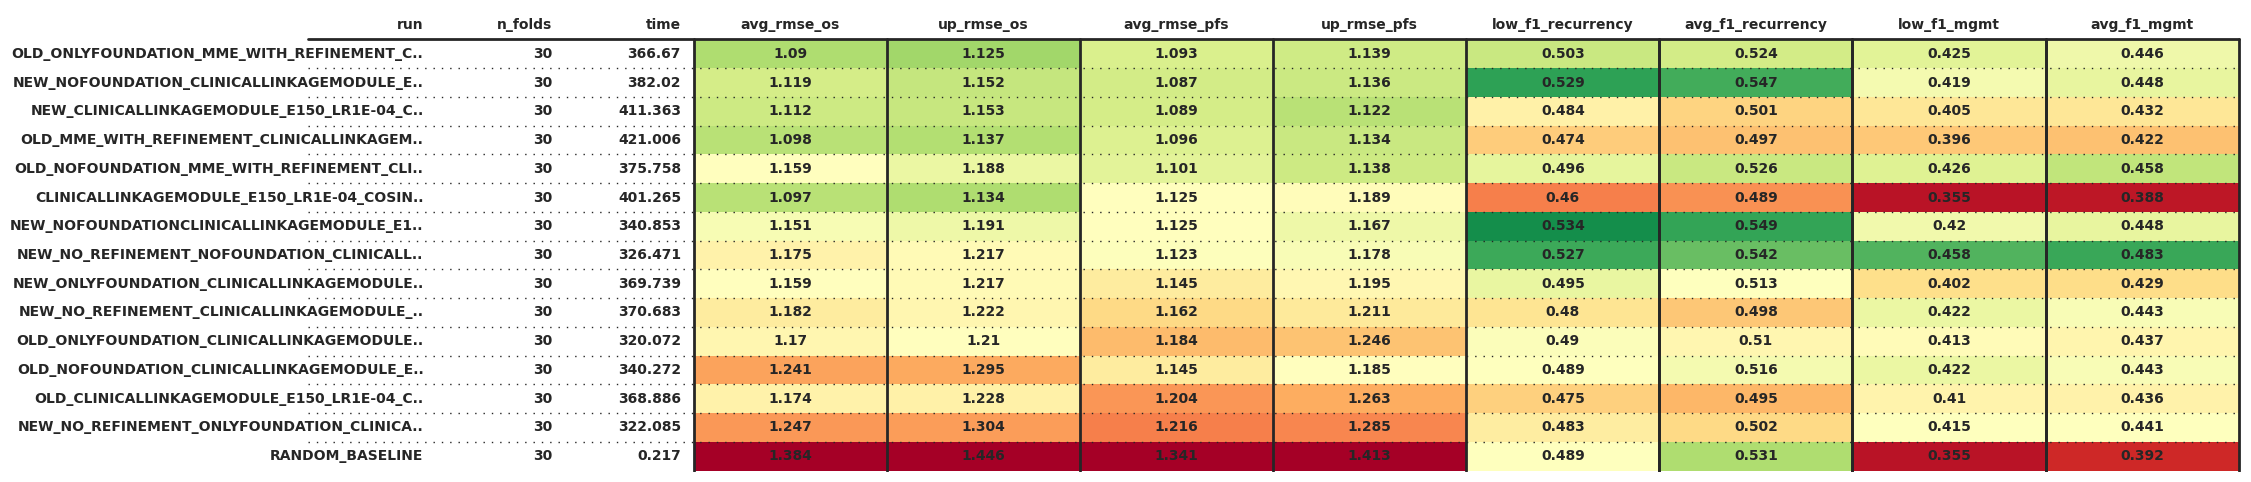

In [14]:
plot_results_cv('../results/cv_results.csv', run_filter='ClinicalLinkage', clip_runs=True)

Same conclusion as before on classification tasks but the modality wise framework withut refinement and using no foundation models embeddings yields slightly better performances on both classification tasks.